# **Análisis Exploratorio de los Datos**

## **Librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

## **Datos**

### **Etiquetas y meta-datos de los audios**

Primeramente, importaremos el conjunto de datos que contiene las etiquetas y metadatos de los audios. Es decir, la base de datos con la que podemos saber a qué especie corresponde cada grabación.

In [2]:
datatrainetiquetas = pd.read_csv('../train.csv')
datatrainetiquetas

,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0


Antes de inciar con el respectivo análisis, tenemos el diccionario de variables que nos permitirá comprender mejor la base de datos. En este orden ideas, 

- **primary_label**: Código de la especie principal en la grabación (eBird para aves, iNaturalist para otros animales).

- **secondary_labels**: Lista de especies adicionales que también aparecen en la grabación según el autor. Puede estar incompleta.

- **type**: Tipo de vocalización de la especie en la grabación. Puede representar cantos, llamados, llamados en vuelo, o una mezcla. 

- **filename**: Nombre del archivo de audio asociado a la grabación.

- **collection**: Fuente de la grabación: `XC` (Xeno-canto), `iNat`(iNaturalist), o `CSA` (Archivo Sonoro Colombiano).

- **rating**: Calidad de la grabación (de 1 a 5) por Xeno-canto; 0 implica que no se asignó ninguna calificación. iNaturalist y CSA no califican sus grabaciones.

- **url**: Enlace al recurso original de la grabación.

- **latitude**: Latitud donde se tomó la grabación.

- **longitude**: Longitud donde se tomó la grabación.

- **scientific_name**: Nombre científico de la especie.

- **common_name**: Nombre común de la especie.

- **author**: Usuario que proporcionó la grabación. Unknown en caso de que no se haya registrado ningún nombre.

- **license**: Tipo de licencia asociada al uso de la grabación.

In [3]:
datatrainetiquetas.shape

(28564, 13)

El conjunto de datos de etiquetas de audio contiene un total de `28564 observaciones`, correspondientes al número de grabaciones recopiladas de diferentes especies animales. Asimismo, se tienen `13 variables descriptivas` que proporcionan metadatos para identificar y caracterizar cada grabación.

In [4]:
datatrainetiquetas.info()
datatrainetiquetas.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28564 entries, 0 to 28563
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     28564 non-null  object 
 1   secondary_labels  28564 non-null  object 
 2   type              28564 non-null  object 
 3   filename          28564 non-null  object 
 4   collection        28564 non-null  object 
 5   rating            28564 non-null  float64
 6   url               28564 non-null  object 
 7   latitude          27755 non-null  float64
 8   longitude         27755 non-null  float64
 9   scientific_name   28564 non-null  object 
 10  common_name       28564 non-null  object 
 11  author            28564 non-null  object 
 12  license           28564 non-null  object 
dtypes: float64(3), object(10)
memory usage: 2.8+ MB


object     10
float64     3
Name: count, dtype: int64

Entre las variables descriptivas, `rating`, `latitude` y `longitude` son de tipo numérico, mientras que las **10 restantes** corresponden a valores tipo textuales.



### **Taxonomía de las especies**

En este caso, también se nos proporciona un conjunto de datos que contiene información taxónomica de las especies a estudiar.

In [5]:
datataxonomy = pd.read_csv('../taxonomy.csv')
datataxonomy

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta
...,...,...,...,...,...
201,yehcar1,1432779,Milvago chimachima,Yellow-headed Caracara,Aves
202,yelori1,9352,Icterus nigrogularis,Yellow Oriole,Aves
203,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flycatcher,Aves
204,yercac1,10359,Cacicus cela,Yellow-rumped Cacique,Aves


Se puede observar que la base de datos cuenta con **206 observaciones**, correspondientes a la cantidad de especies únicas. Además, contiene **5 variables descriptivas**. De estas, 3 son compartidas con la base de etiquetas y metadatos, siendo: `primary_label`, `scientific_name` y `common_name`. En cuanto a las variables restantes, se describen a continuación:

- **inat_taxon_id**: Identificador único que iNaturalist asigna a cada especie. 

- **class_name**: Clase biológica a la que pertenece la especie (Aves, Amphibia, Mammalia o Insecta).

In [6]:
datataxonomy.info()
datataxonomy.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   primary_label    206 non-null    object
 1   inat_taxon_id    206 non-null    int64 
 2   scientific_name  206 non-null    object
 3   common_name      206 non-null    object
 4   class_name       206 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.2+ KB


object    4
int64     1
Name: count, dtype: int64

Entre las variables, solo `inat_taxon_id` resultó ser de tipo numérico, mientras que las **4 restantes** corresponden a valores tipo textuales.

### **Merge: Base de datos**

Ahora, con el fin de aprovechar toda la información disponible y enriquecer el análisis a realizar, se procederá a unir las dos bases de datos. Así, contamos con un conjunto más completo y robusto para los procesos posteriores.

De esta forma, obtenemos `datatrain`.

In [7]:
taxo_info = datataxonomy[['primary_label', 'inat_taxon_id', 'class_name']]
datatrain = datatrainetiquetas.merge(taxo_info, how='left', on='primary_label')
datatrain

,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,inat_taxon_id,class_name
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0,19003,Aves
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0,19003,Aves
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0,19003,Aves
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0,19003,Aves


Con el conjunto de datos a utilizar ya completo, procedemos a identificar si hay existencia de datos faltantes.

Para esto, vamos a contarlos y graficarlos.

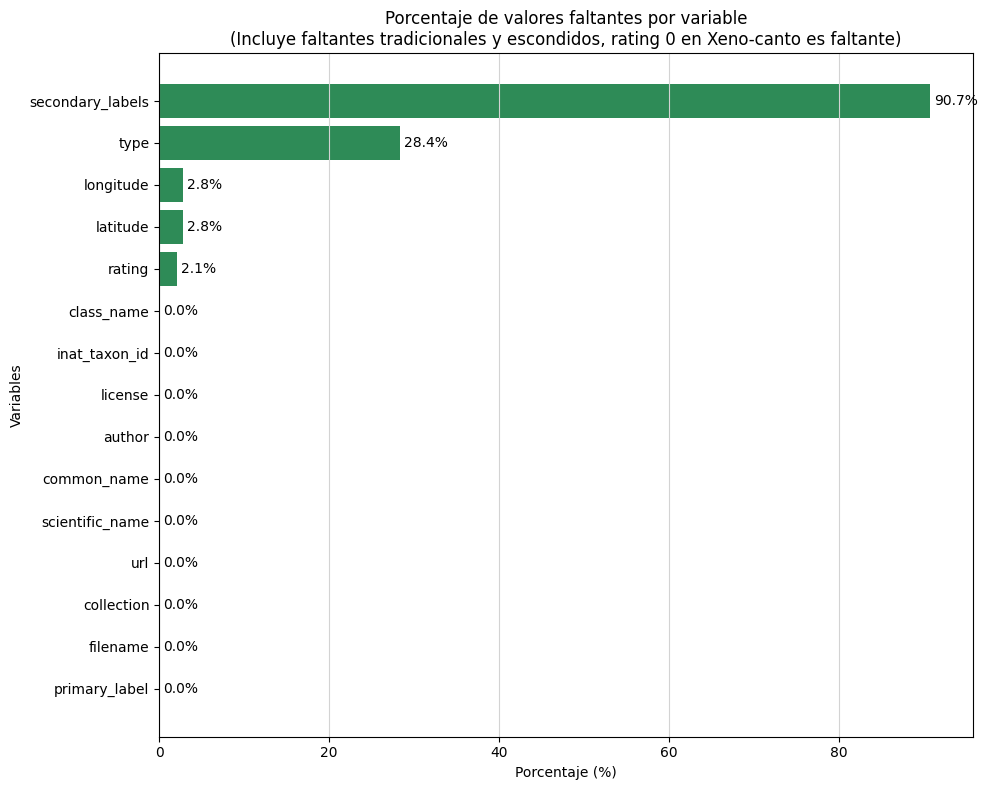

In [8]:
def detectarfaltantes(valor, columna=None, fila=None):
    import numpy as np
    if pd.isna(valor):
        return True
    if isinstance(valor, str):
        vacios_comunes = ['', '[]', "['']", 'nan', 'null', 'None']
        return valor.strip() in vacios_comunes
    if columna == 'rating':
        if valor == 0 and fila['collection'] == 'XC':
            return True
    return False

var_texto = datatrain.select_dtypes(include=['object']).columns
missing_total = {}

for col in datatrain.columns:
    tradicionales = datatrain[col].isnull().sum()

    escondidos = 0
    if col in var_texto:
        escondidos = datatrain[col].apply(lambda x: detectarfaltantes(x, columna=col, fila=None)).sum() - tradicionales
    elif col == 'rating':
        # Para rating necesitamos pasar la fila completa para saber la fuente
        escondidos = datatrain.apply(lambda row: detectarfaltantes(row['rating'], columna='rating', fila=row), axis=1).sum() - tradicionales

    total_faltantes = tradicionales + escondidos
    porcentaje_total = (total_faltantes / len(datatrain)) * 100
    missing_total[col] = porcentaje_total

missing_series = pd.Series(missing_total).sort_values(ascending=False)
missingdatatrain = pd.DataFrame({
    'Variable': missing_series.index,
    'Porcentaje_faltantes_total': missing_series.values
})


df_sorted = missingdatatrain.sort_values('Porcentaje_faltantes_total')

plt.figure(figsize=(10, 8))
bars = plt.barh(df_sorted['Variable'], df_sorted['Porcentaje_faltantes_total'], color='#2E8B57')

plt.xlabel('Porcentaje (%)')
plt.ylabel('Variables')
plt.title('Porcentaje de valores faltantes por variable\n(Incluye faltantes tradicionales y escondidos, rating 0 en Xeno-canto es faltante)')
plt.xlim(0, df_sorted['Porcentaje_faltantes_total'].max() + 5)
plt.grid(axis='x', color='lightgrey')

# Añadir texto con porcentaje a la derecha de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

plt.tight_layout()
plt.show()



A partir del gráfico podemos observar que **5 variables** presentan ausencia de registros en distintas proporciones.

En particular, la columna `secondary_labels` muestra un porcentaje de datos faltantes considerablemente alto, lo cual sugiere que no aporta información suficiente para el análisis. Por esta razón, se considera su eliminación del conjunto de datos.

Respecto a `type (28.4%)`, que corresponde al tipo de sonido emitido por el animal, se opta por borrarla de la base de datos puesto que se basa en consideraciones subjetivas que también pueden causar sesgo dentro de los modelos.

In [9]:
datatrain = datatrain.drop(columns=['secondary_labels', 'type'])
datatrain 

,primary_label,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,inat_taxon_id,class_name
0,1139490,1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
1,1139490,1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
2,1192948,1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
3,1192948,1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
4,1192948,1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0,19003,Aves
28560,ywcpar,ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0,19003,Aves
28561,ywcpar,ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0,19003,Aves
28562,ywcpar,ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0,19003,Aves


Con respecto a `rating`, `latitude` y `longitude` , vamos a realizar la imputación de datos.

Cabe mencionar que la detección de datos faltantes en la variable `rating` se basó en aquellos registros correspondientes a la fuente de datos **Xeno-canto** que tuvieran como puntuación el valor **0**.

### **Imputación de datos faltantes**

In [10]:
# datatrain.loc[datatrain['rating'].notna(), 'rating'] = np.floor(datatrain.loc[datatrain['rating'].notna(), 'rating']).astype(int)

mask_xc_0 = (datatrain['collection'] == 'XC') & (datatrain['rating'] == 0)
datatrain.loc[mask_xc_0, 'rating'] = np.nan

moda = datatrain['rating'].mode().iloc[0]
datatrain['rating'] = datatrain['rating'].fillna(moda)

#### **K-Nearest Neighbors**

Para estimar estos valores faltantes, se aplicará el método de imputación basado en **K-Nearest Neighbors (KNN)**.

Este enfoque consiste en encontrar, para cada registro incompleto, un conjunto de observaciones similares (sus k vecinos más cercanos) a partir de variables relevantes, y asignarles coordenadas calculadas en función de dichos vecinos.

In [11]:
def imputacionknn(df, k=5):
    
    df_completo = df.dropna(subset=['latitude', 'longitude']).copy() # Filas con NA
    df_incompleto = df[df[['latitude', 'longitude']].isna().any(axis=1)].copy() # Filas sin NA
    
    if df_incompleto.empty:
        return df
    
    cols = df.columns.to_list()
    nofeatures = ['filename', 'url', 'rating']

    features = [col for col in cols if col not in nofeatures + ['latitude', 'longitude']]

    cat_features = [f for f in features if (datatrain[f].dtype == 'object')] # Variables textuales
    num_features = [f for f in features if (datatrain[f].dtype != 'object')] # Variables numéricas


    # Preprocesamiento
    transformers = []
    if cat_features: # OneHotEncoder para variables textuales
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features))
    if num_features: # Nada para variables numéricas
        transformers.append(('num', 'passthrough', num_features))
    
    preprocessor = ColumnTransformer(transformers)
    
    for idx, row in df_incompleto.iterrows():
        especie = row['primary_label']
        subset = df_completo[df_completo['primary_label'] == especie]
        
        if len(subset) < k and 'scientific_name' in df.columns:
            subset = df_completo[df_completo['scientific_name'] == row['scientific_name']]
        
        if len(subset) < k:
            subset = df_completo
        
        if len(subset) == 0:
            continue
        
        k_efectivo = min(k, len(subset)) # Máximo k disponible
        
        X_subset = preprocessor.fit_transform(subset[features])
        X_pred = preprocessor.transform(pd.DataFrame([row[features]]))

        # Buscar k vecinos más cercanos
        nbrs = NearestNeighbors(n_neighbors=k_efectivo)
        nbrs.fit(X_subset)
        distances, indices = nbrs.kneighbors(X_pred)

        vecinos_coords = subset.iloc[indices[0]]

        # Calcular medianas para imputar
        lat_mediana = np.median(vecinos_coords['latitude'])
        lon_mediana = np.median(vecinos_coords['longitude'])

        df_incompleto.at[idx, 'latitude'] = lat_mediana
        df_incompleto.at[idx, 'longitude'] = lon_mediana

    return pd.concat([df_completo, df_incompleto], ignore_index=True)


In [12]:
datatrain_prueba1 = imputacionknn(datatrain, k=5)

In [13]:
datatrain_prueba1.isnull().sum()

primary_label      0
filename           0
collection         0
rating             0
url                0
latitude           0
longitude          0
scientific_name    0
common_name        0
author             0
license            0
inat_taxon_id      0
class_name         0
dtype: int64

#### **API de GBIF**

In [12]:
import requests

def coordenadasgbif(nombre_especie, max_resultados=50):
    
    url = "https://api.gbif.org/v1/occurrence/search"
    params = {
        "scientificName": nombre_especie,
        "hasCoordinate": "true",
        "limit": max_resultados,
        "basisOfRecord": ["HUMAN_OBSERVATION", "MACHINE_OBSERVATION", "PRESERVED_SPECIMEN"]
    }

    try:
        respuesta = requests.get(url, params=params, timeout=10)
        respuesta.raise_for_status()
    except requests.RequestException as e:
        print(f"Error al consultar GBIF para {nombre_especie}: {e}")
        return []

    datos = respuesta.json()
    coords = []

    for registro in datos.get("results", []):
        lat = registro.get("decimalLatitude")
        lon = registro.get("decimalLongitude")
        if lat is not None and lon is not None and -90 <= lat <= 90 and -180 <= lon <= 180:
            coords.append((lat, lon))

    return coords

def imputacionapi(df, especie_col='scientific_name', lat_col='latitude', lon_col='longitude'):
    
    faltantes = df[df[lat_col].isna() | df[lon_col].isna()]

    for idx, fila in faltantes.iterrows():
        especie = fila[especie_col]

        if pd.isna(especie):
            continue
        
        coords = coordenadasgbif(especie)

        if coords:
            latitudes, longitudes = zip(*coords)
            med_lat = np.median(latitudes)
            med_lon = np.median(longitudes)

            df.at[idx, lat_col] = med_lat
            df.at[idx, lon_col] = med_lon

    return df

In [13]:
datatrain_prueba2 = imputacionapi(datatrain, especie_col='scientific_name', lat_col='latitude', lon_col='longitude')

In [14]:
datatrain_prueba2.isnull().sum()

primary_label      0
filename           0
collection         0
rating             0
url                0
latitude           6
longitude          6
scientific_name    0
common_name        0
author             0
license            0
inat_taxon_id      0
class_name         0
dtype: int64

In [15]:
datatrain_prueba2[datatrain_prueba2.isna().any(axis=1)]

,primary_label,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,inat_taxon_id,class_name
11927,gycwor1,gycwor1/XC290412.ogg,XC,5.0,https://xeno-canto.org/290412,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Dennys Plazas,cc-by-nc-sa 4.0,513889,Aves
12025,gycwor1,gycwor1/XC61172.ogg,XC,3.0,https://xeno-canto.org/61172,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Bernabe Lopez-Lanus,cc-by-nc-sa 3.0,513889,Aves
12051,gycwor1,gycwor1/XC73102.ogg,XC,4.0,https://xeno-canto.org/73102,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Joseph Tobias and Nathalie Seddon,cc-by-nc-sa 3.0,513889,Aves
12052,gycwor1,gycwor1/XC73103.ogg,XC,5.0,https://xeno-canto.org/73103,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Joseph Tobias and Nathalie Seddon,cc-by-nc-sa 3.0,513889,Aves
12076,gycwor1,gycwor1/XC832982.ogg,XC,4.0,https://xeno-canto.org/832982,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Sabrina Andrea Rendon Anaya,cc-by-nc-sa 4.0,513889,Aves
12084,gycwor1,gycwor1/XC862572.ogg,XC,5.0,https://xeno-canto.org/862572,NaN,NaN,Aramides cajaneus,Gray-cowled Wood-Rail,Jacob Wijpkema,cc-by-nc-sa 4.0,513889,Aves


In [16]:
import pickle

with open('datatrain_prueba2.pkl', 'wb') as f:
    pickle.dump(datatrain_prueba2, f)


#### **Conclusión**

Para la imputación de las coordenadas geográficas se aplicaron dos métodos por separado. Al comparar los resultados, se observó que el método de **K-nearest neighbors** completó la imputación en todas las observaciones con datos faltantes, mientras que la imputación mediante la **API de GBIF** no logró cubrir todos los casos, dado que algunas observaciones no pudieron ser identificadas y, por ende, no se imputaron. Por esta razón, el análisis continuará utilizando la base de datos resultante del primer método.

In [14]:
datatrain_ = datatrain.copy()
datatrain = datatrain_prueba1

### **Base de datos: Colombia**

Dado que nuestro lugar de interés es el territorio colombiano, vamos a filtrar la base de datos para quedarnos únicamente con los registros grabados en el país.

Para esto, usaremos un archivo **shapefile** descargado del sitio [DIVA-GIS](https://diva-gis.org/data.html) que nos permitirá seleccionar únicamente las observaciones cuyas coordenadas geográficas se encuentren dentro de los límites definidos para Colombia en dicho archivo.

In [15]:
colombia_shp = gpd.read_file("../COL_adm/COL_adm0.shp")
colombia_shp = colombia_shp.to_crs('EPSG:4326')

# Crear puntos geométricos de tus coordenadas
geometry = [Point(xy) for xy in zip(datatrain['longitude'], datatrain['latitude'])]
geo_df = gpd.GeoDataFrame(datatrain, geometry=geometry, crs='EPSG:4326')

join_result = gpd.sjoin(geo_df, colombia_shp, how='inner', predicate='within')

index_colombia = join_result.index

datatraincolombia = datatrain.loc[index_colombia].copy()


print(f"Registros en Colombia: {len(datatraincolombia)}")
print(f"Registros fuera de Colombia: {len(datatrain) - len(datatraincolombia)}")
print(f"Porcentaje en Colombia: {(len(datatraincolombia)/len(datatrain))*100:.1f}%")

Registros en Colombia: 5090
Registros fuera de Colombia: 23474
Porcentaje en Colombia: 17.8%


In [16]:
datatraincolombia

,primary_label,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,inat_taxon_id,class_name
0,1139490,1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
1,1139490,1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1139490,Insecta
2,1192948,1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
3,1192948,1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
4,1192948,1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,1192948,Insecta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28528,yehcar1,yehcar1/XC112641.ogg,XC,4.0,https://xeno-canto.org/112641,5.1304,-68.3063,Milvago chimachima,Yellow-headed Caracara,Daniel Blamires,cc-by-nc-sa 3.0,1432779,Aves
28535,yelori1,yelori1/XC56592.ogg,XC,5.0,https://xeno-canto.org/56592,4.7820,-71.7740,Icterus nigrogularis,Yellow Oriole,Bernabe Lopez-Lanus,cc-by-nc-sa 3.0,9352,Aves
28536,yelori1,yelori1/XC57481.ogg,XC,4.0,https://xeno-canto.org/57481,4.7820,-71.7740,Icterus nigrogularis,Yellow Oriole,Bernabe Lopez-Lanus,cc-by-nc-sa 3.0,9352,Aves
28537,yelori1,yelori1/XC57482.ogg,XC,4.0,https://xeno-canto.org/57482,4.7820,-71.7740,Icterus nigrogularis,Yellow Oriole,Bernabe Lopez-Lanus,cc-by-nc-sa 3.0,9352,Aves


Finalmente nos quedamos con un conjunto de datos correspondiente a **5090 grabaciones** y **13 variables descriptivas**.

Seguiremos con el análisis de estas.

## **Análisis univariado**

### **primary_label**

In [17]:
datatraincolombia['primary_label'].nunique()

182

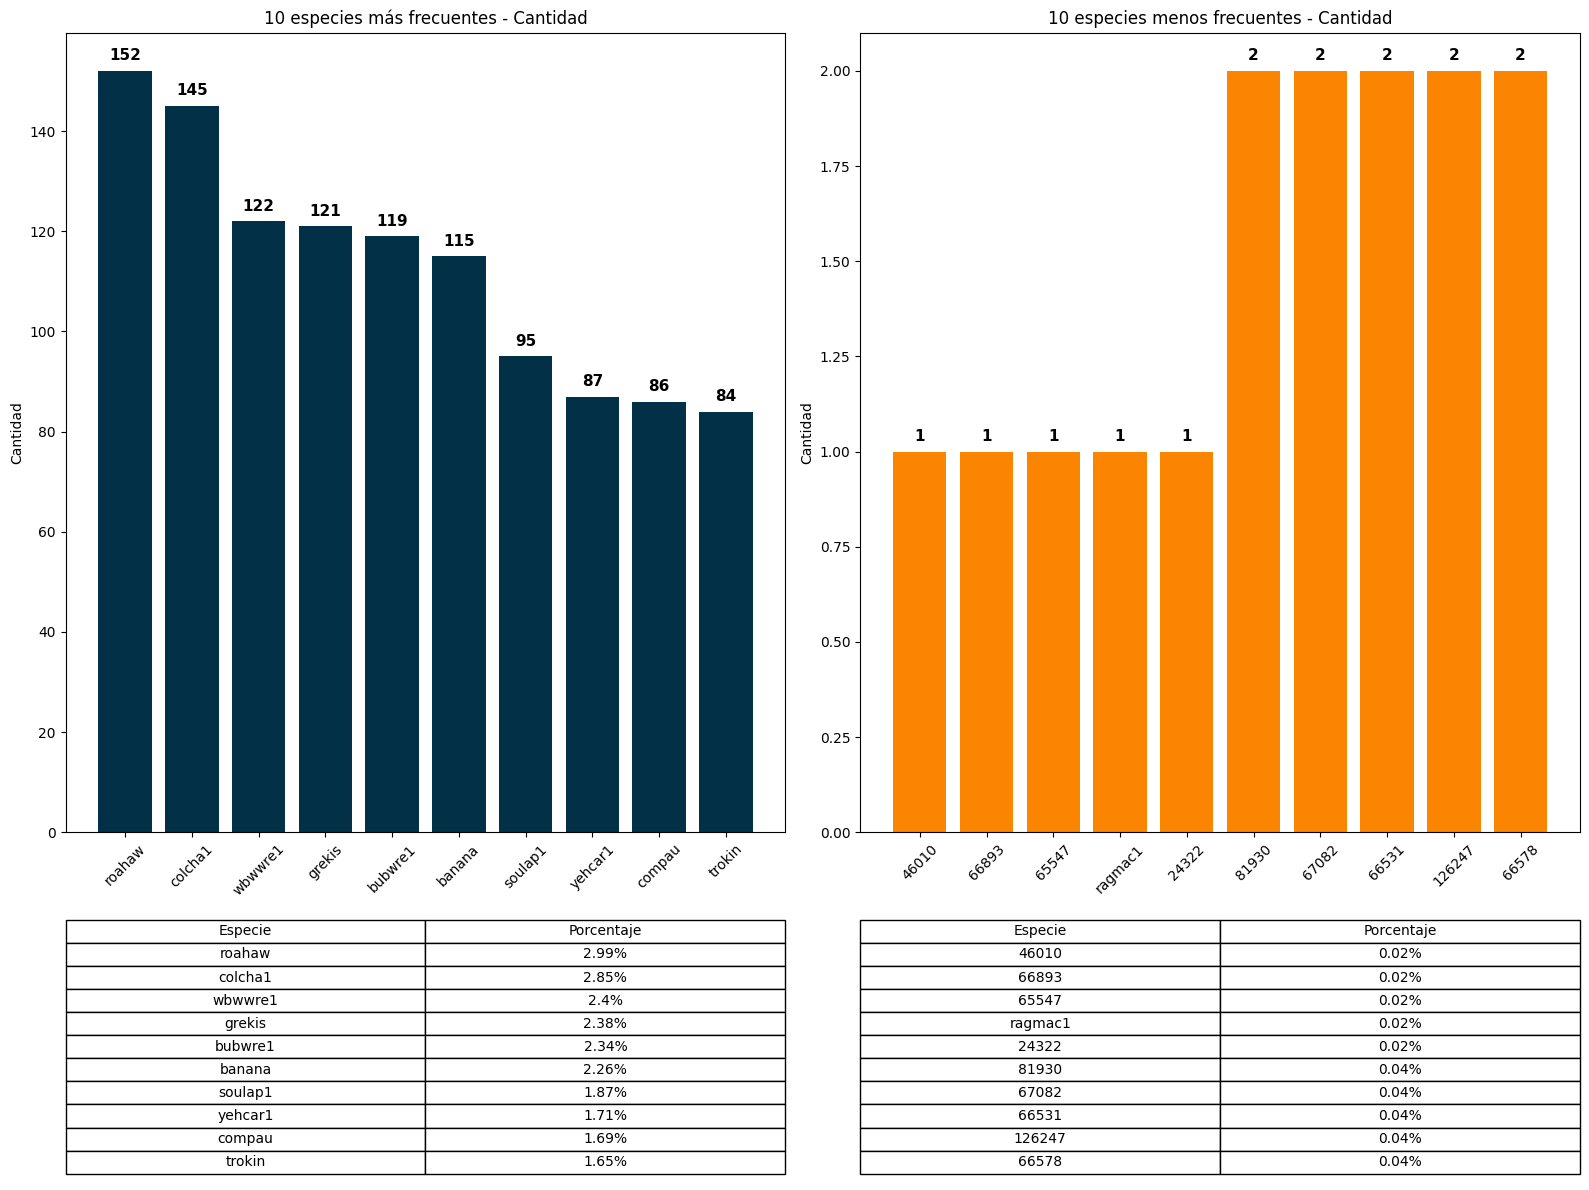

In [18]:
frecuenciacodigos = datatraincolombia['primary_label'].value_counts()

top10codigos = frecuenciacodigos.nlargest(10).reset_index()
top10codigos.columns = ['primary_label', 'count']

least10codigos = frecuenciacodigos.nsmallest(10).reset_index()
least10codigos.columns = ['primary_label', 'count']

for df_ in [top10codigos, least10codigos]:
    df_['percentage'] = (df_['count'] / len(datatraincolombia) * 100).round(2)

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1], 'width_ratios': [3, 3]})
plt.subplots_adjust(hspace=0.4)

bars_top = axs[0, 0].bar(top10codigos['primary_label'], top10codigos['count'], color='#023047')
axs[0, 0].set_title('10 especies más frecuentes - Cantidad')
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].set_ylabel('Cantidad')

for bar in bars_top:
    height = bar.get_height()
    axs[0, 0].text(bar.get_x() + bar.get_width()/2, height + max(top10codigos['count'])*0.01, f'{int(height)}', 
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

cell_text_top = [[top10codigos['primary_label'].iloc[i], f"{top10codigos['percentage'].iloc[i]}%"]
                 for i in range(len(top10codigos))]
axs[1, 0].axis('tight')
axs[1, 0].axis('off')
table_top = axs[1, 0].table(cellText=cell_text_top,
                            colLabels=["Especie", "Porcentaje"],
                            loc='center',
                            cellLoc='center')
table_top.auto_set_font_size(False)
table_top.set_fontsize(10)

bars_least = axs[0, 1].bar(least10codigos['primary_label'], least10codigos['count'], color='#fb8500')
axs[0, 1].set_title('10 especies menos frecuentes - Cantidad')
axs[0, 1].tick_params(axis='x', rotation=45)
axs[0, 1].set_ylabel('Cantidad')

for bar in bars_least:
    height = bar.get_height()
    axs[0, 1].text(bar.get_x() + bar.get_width()/2, height + max(least10codigos['count'])*0.01, f'{int(height)}', 
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

cell_text_least = [[least10codigos['primary_label'].iloc[i], f"{least10codigos['percentage'].iloc[i]}%"]
                   for i in range(len(least10codigos))]
axs[1, 1].axis('tight')
axs[1, 1].axis('off')
table_least = axs[1, 1].table(cellText=cell_text_least,
                              colLabels=["Especie", "Porcentaje"],
                              loc='center',
                              cellLoc='center')
table_least.auto_set_font_size(False)
table_least.set_fontsize(10)

plt.tight_layout()
plt.show()



Según los registros de la base de datos a analizar, Colombia cuenta con un total de **182 especies únicas**.

A partir de los datos, podemos afirmar que existe un marcado desbalance entre estas, ya que las 10 especies con mayor frecuencia varían entre **84 y 152 observaciones**, mientras que algunas especies cuentan con solo **1 o 2 registros**.

Entre las 182 especies, la que registró más grabaciones corresponde al código **roahaw**, mientras que aquellas con solo 1 observación incluyen los códigos **46010, 66893, 65547, ragmac1 y 24322**.

Las 10 especies más frecuentes representan el **22.14%** del total de observaciones, mientras que las 10 menos frecuentes solo alcanzan un **0.3%**.

### **filename**

In [19]:
datatraincolombia['filename'].nunique()

5090

Dado que la cantidad de nombres únicos de grabaciones es de **5090**, igual al tamaño total de la base, podemos concluir que no existen grabaciones duplicadas ni registros que correspondan a un mismo archivo.

### **collection**

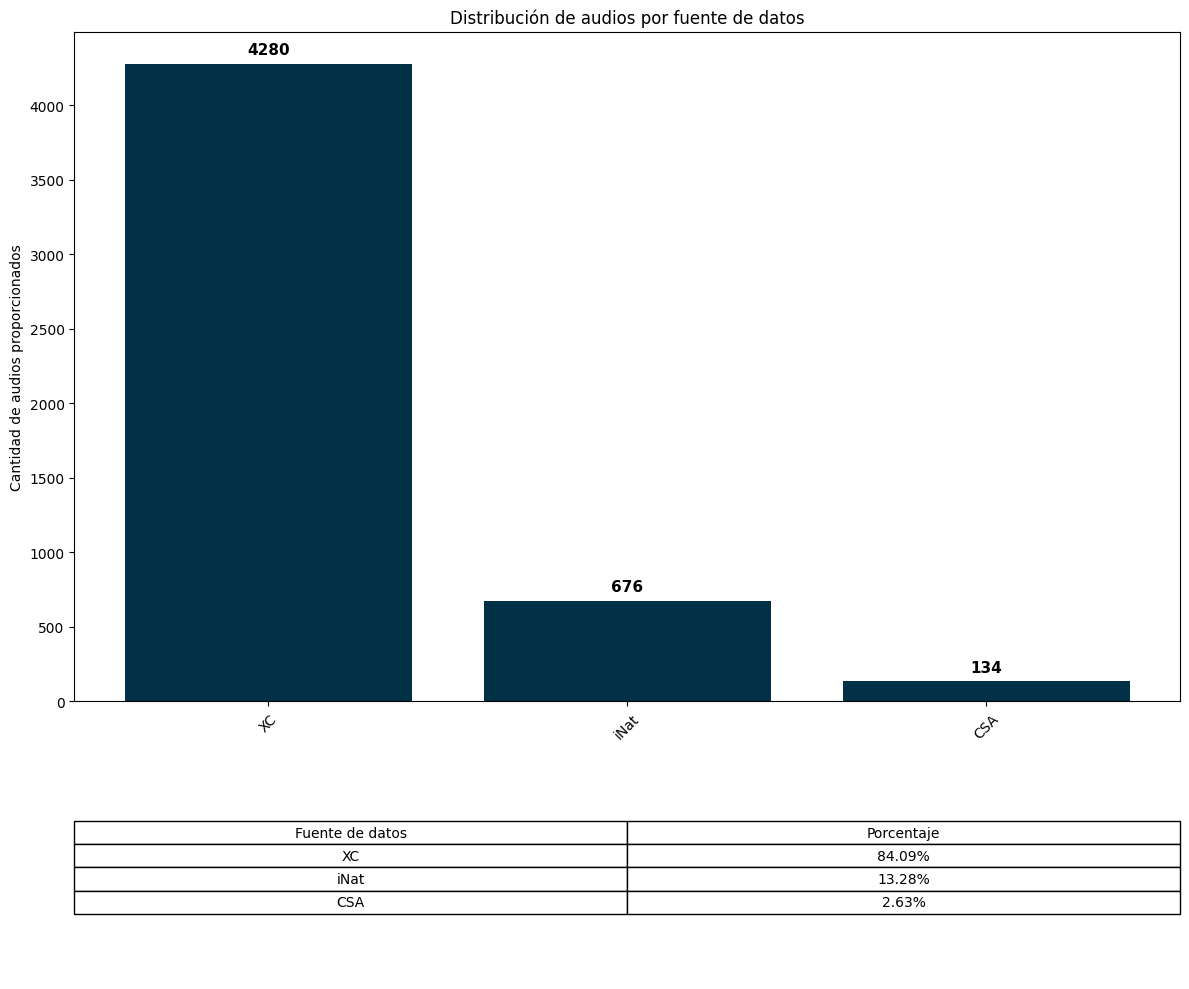

In [20]:
freqcollection = datatraincolombia['collection'].value_counts().reset_index()
freqcollection.columns = ['collection', 'count']

freqcollection['percentage'] = (freqcollection['count'] / len(datatraincolombia) * 100).round(2)

fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.4)

bars = axs[0].bar(freqcollection['collection'], freqcollection['count'], color='#023047')
axs[0].set_title('Distribución de audios por fuente de datos')
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_ylabel('Cantidad de audios proporcionados')

for bar in bars:
    height = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, height + max(freqcollection['count'])*0.01, 
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

cell_text = [[freqcollection['collection'].iloc[i], f"{freqcollection['percentage'].iloc[i]}%"]
             for i in range(len(freqcollection))]
axs[1].axis('tight')
axs[1].axis('off')
table = axs[1].table(cellText=cell_text,
                    colLabels=["Fuente de datos", "Porcentaje"],
                    loc='center',
                    cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.show()


Respecto a las fuentes de datos que proporcionaron los audios, podemos destacar que la gran mayoría proviene de Xeno-canto, representando el **84.09%** del total de grabaciones. El porcentaje restante se distribuye entre iNaturalist con un **13.28%** y el Archivo Sonoro Colombiano con un **2.63%**.

### **rating**

	

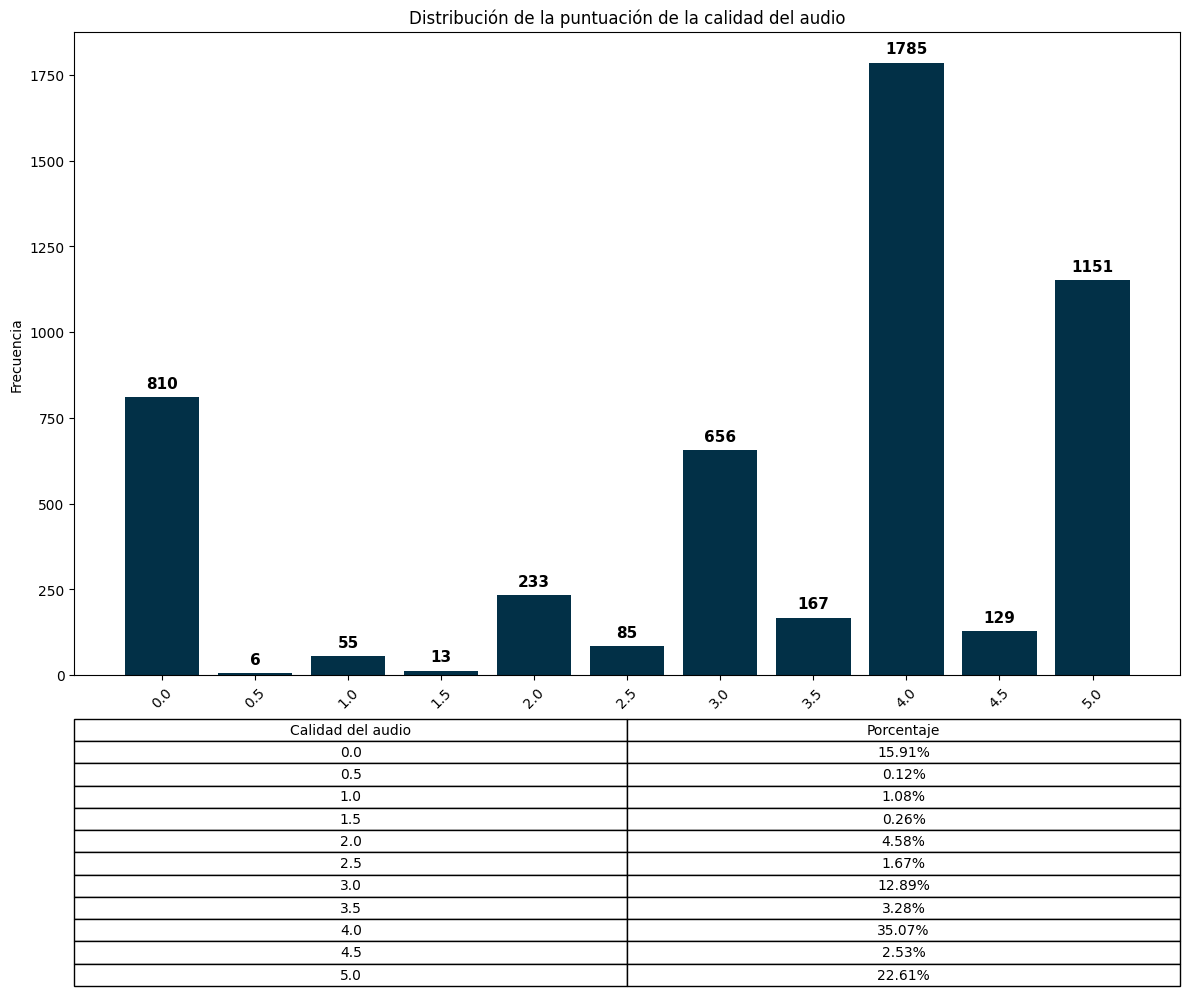

In [21]:
freqrating = datatraincolombia['rating'].value_counts().reset_index()
freqrating.columns = ['rating', 'count']

freqrating['percentage'] = (freqrating['count'] / len(datatraincolombia) * 100).round(2)



freqrating_sorted = freqrating.sort_values(by='rating')

fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.4)

# Gráfico de barras con frecuencias
bars = axs[0].bar(freqrating_sorted['rating'].astype(str), freqrating_sorted['count'], color='#023047')
axs[0].set_title('Distribución de la puntuación de la calidad del audio')
axs[0].set_ylabel('Frecuencia')
axs[0].tick_params(axis='x', rotation=45)

# Números arriba de las barras
for bar in bars:
    height = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, height + max(freqrating_sorted['count'])*0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tabla con porcentajes ordenada igual
cell_text = [[str(freqrating_sorted['rating'].iloc[i]), f"{freqrating_sorted['percentage'].iloc[i]}%"] 
             for i in range(len(freqrating_sorted))]
axs[1].axis('tight')
axs[1].axis('off')
table = axs[1].table(cellText=cell_text,
                    colLabels=["Calidad del audio", "Porcentaje"],
                    loc='center',
                    cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.show()




### **latitude - longitude**

In [22]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # IMPORTANTE

lat_mean = datatraincolombia['latitude'].mean()
lon_mean = datatraincolombia['longitude'].mean()

m = folium.Map(location=[lat_mean, lon_mean], zoom_start=5, tiles='OpenStreetMap')

collections = datatraincolombia['collection'].unique()
cmap = plt.cm.get_cmap('tab10', len(collections))

# Usa mcolors.rgb2hex en lugar de plt.colors.rgb2hex
color_dict = {collection: mcolors.rgb2hex(cmap(i)) for i, collection in enumerate(collections)}

for _, row in datatraincolombia.iterrows():
    color = color_dict[row['collection']]
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Collection: {row['collection']}"
    ).add_to(m)

m

C:\Users\valcd\AppData\Local\Temp\ipykernel_18040\2922528606.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(collections))


In [23]:
departamentosshp = "../COL_adm/COL_adm1.shp"  
gdf_departamentos = gpd.read_file(departamentosshp).to_crs(epsg=4326)

geometry = [Point(xy) for xy in zip(datatraincolombia['longitude'], datatraincolombia['latitude'])]
gdfpuntosdpto = gpd.GeoDataFrame(datatraincolombia, geometry=geometry, crs="EPSG:4326")

gdfjoindepto = gpd.sjoin(gdfpuntosdpto, gdf_departamentos, how="left", predicate="within")

countdepto = gdfjoindepto['NAME_1'].value_counts().reset_index()
countdepto.columns = ['Departamento', 'Cantidad']

countdepto['Porcentaje'] = (countdepto['Cantidad'] / len(datatraincolombia) * 100).round(2)

tabla1 = countdepto.style.set_table_attributes('style="width: 60%; margin: auto;"') \
    .set_caption("Cantidad y Porcentaje por Departamento") \
    .background_gradient(subset=['Cantidad', 'Porcentaje'], cmap='Blues') \
    .format({'Porcentaje': '{:.2f}%'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#023047'), ('color', 'white')]},
        {'selector': 'td.col0', 'props': [('background-color', 'white'), ('color', 'black')]}  # Solo columna Departamento texto negro y fondo blanco
    ])

display(tabla1)

,Departamento,Cantidad,Porcentaje
0,Cundinamarca,759,14.91%
1,Antioquia,635,12.48%
2,Caquetá,358,7.03%
3,Valle del Cauca,337,6.62%
4,Tolima,310,6.09%
5,Santander,304,5.97%
6,Caldas,226,4.44%
7,Risaralda,222,4.36%
8,Casanare,197,3.87%
9,Magdalena,195,3.83%


El mapa nos permite visualizar la distribución de las grabaciones a partir de sus coordenadas geográficas dentro del territorio colombiano. Tal como era de esperarse, se observa una fuerte presencia de datos provenientes de la fuente **Xeno-canto**, ya que el color de puntos correspondiente a esta es el que más predomina a simple vista.

Asimismo, se aprecia una alta concentración de grabaciones en departamentos ubicados en la región andina y zonas cercanas. Esto se confirma con la tabla, donde Cundinamarca registra la mayor cantidad de grabaciones siendo esta de **759 (14.91%)**, seguida por Antioquia con **635 (12.48%)** y Caquetá con **358 (7.03%)**.

### **scientific_name**

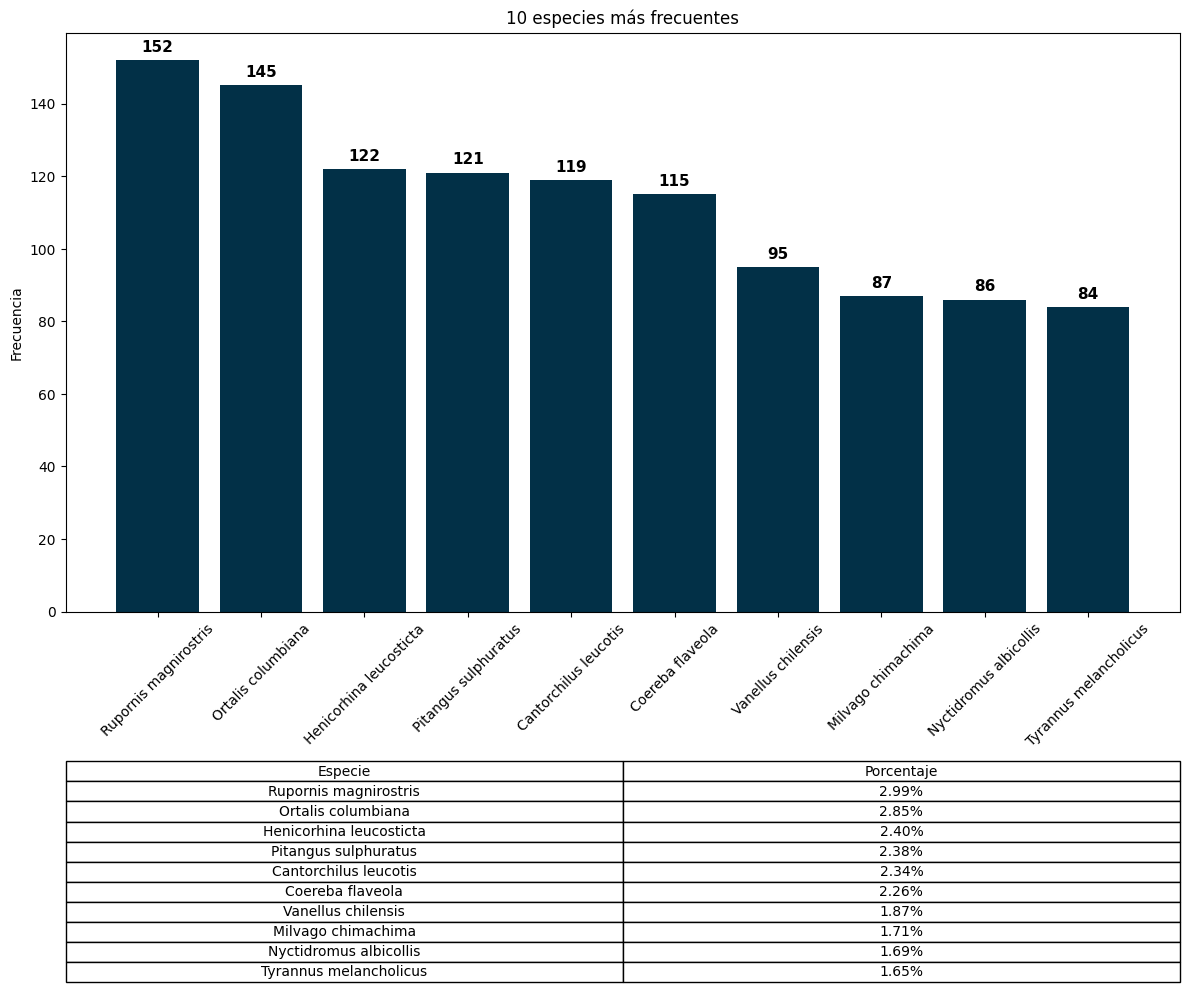

In [24]:
freqscientificname = datatraincolombia['scientific_name'].value_counts()

top10especienc = freqscientificname.nlargest(10).reset_index()
top10especienc.columns = ['scientific_name', 'count']
top10especienc['percentage'] = (top10especienc['count'] / len(datatraincolombia) * 100).round(2)

top10especienc = freqscientificname.nlargest(10).reset_index()
top10especienc.columns = ['scientific_name', 'count']
top10especienc['percentage'] = (top10especienc['count'] / len(datatraincolombia) * 100)

fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.4)

# Gráfico de barras con frecuencias
bars = axs[0].bar(top10especienc['scientific_name'], top10especienc['count'], color='#023047')
axs[0].set_title('10 especies más frecuentes')
axs[0].set_ylabel('Frecuencia')
axs[0].tick_params(axis='x', rotation=45)

# Números arriba de las barras
for bar in bars:
    height = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, height + max(top10especienc['count']) * 0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tabla con porcentajes
cell_text = [[top10especienc['scientific_name'].iloc[i], f"{top10especienc['percentage'].iloc[i]:.2f}%"]
             for i in range(len(top10especienc))]
axs[1].axis('tight')
axs[1].axis('off')
table = axs[1].table(cellText=cell_text,
                    colLabels=["Especie", "Porcentaje"],
                    loc='center',
                    cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.show()

A partir del gráfico se identifican los nombres científicos de **las 10 especies con mayor número de registros** en la base de datos. En este caso, dado que la cantidad de grabaciones por especie varía entre **84 y 152**, puede considerarse que este subgrupo presenta una distribución relativamente equilibrada, sin diferencias extremas en el número de observaciones. Tal como se anticipaba tras analizar `primary_label`, estas 10 especies representan el `22.14%` del total de observaciones del conjunto filtrado por Colombia.

### **author**

In [30]:
datatraincolombia['author'].nunique()

442

In [25]:
countauthor = datatraincolombia['author'].value_counts().reset_index()
countauthor.columns = ['Autor', 'Cantidad de grabaciones']

countauthor['Porcentaje'] = (countauthor['Cantidad de grabaciones'] / len(datatraincolombia) * 100).round(2)

countauthor_top10 = countauthor.head(10)

tabla2 = countauthor_top10.style.set_table_attributes('style="width: 60%; margin: auto;"') \
    .set_caption("Cantidad y Porcentaje por Autor (Top 10)") \
    .background_gradient(subset=['Cantidad de grabaciones', 'Porcentaje'], cmap='Blues') \
    .format({'Porcentaje': '{:.2f}%'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#023047'), ('color', 'white')]},
        {'selector': 'td.col0', 'props': [('background-color', 'white'), ('color', 'black')]},  # Columna Autor fondo blanco y texto negro
        {'selector': 'td', 'props': [('padding', '8px')]}
    ])

display(tabla2)

,Autor,Cantidad de grabaciones,Porcentaje
0,Jerome Fischer,339,6.66%
1,Mauricio Álvarez-Rebolledo (Colección de Sonidos Ambientales - Instituto Humboldt),285,5.60%
2,Andres Angulo,238,4.68%
3,Mauricio Cuellar Ramirez (@Birding.travel),218,4.28%
4,Bernabe Lopez-Lanus,167,3.28%
5,Oswaldo Cortes,166,3.26%
6,Unknown,164,3.22%
7,Cristian Rodas,163,3.20%
8,Yair Guillermo Molina Martínez.,151,2.97%
9,Oscar Humberto Marín Gómez,143,2.81%


Se observa que el autor con mayor aporte fue Jerome Fischer, con 339 grabaciones, seguido por Mauricio Álvarez-Rebolledo  con 285, Andres Angulo con 238 y Mauricio Cuellar Ramirez con 218 grabaciones.

El resto de los autores en el top 10 presentan una menor variabilidad en sus contribuciones, con valores que oscilan entre 143 y 167 grabaciones.

Este grupo de los 10 principales autores representa el **39.96%** del total de grabaciones en el conjunto de datos. Es importante destacar que se incluye la categoría "Unknown", que corresponde a 164 grabaciones sin autor registrado. 

### **class_name**

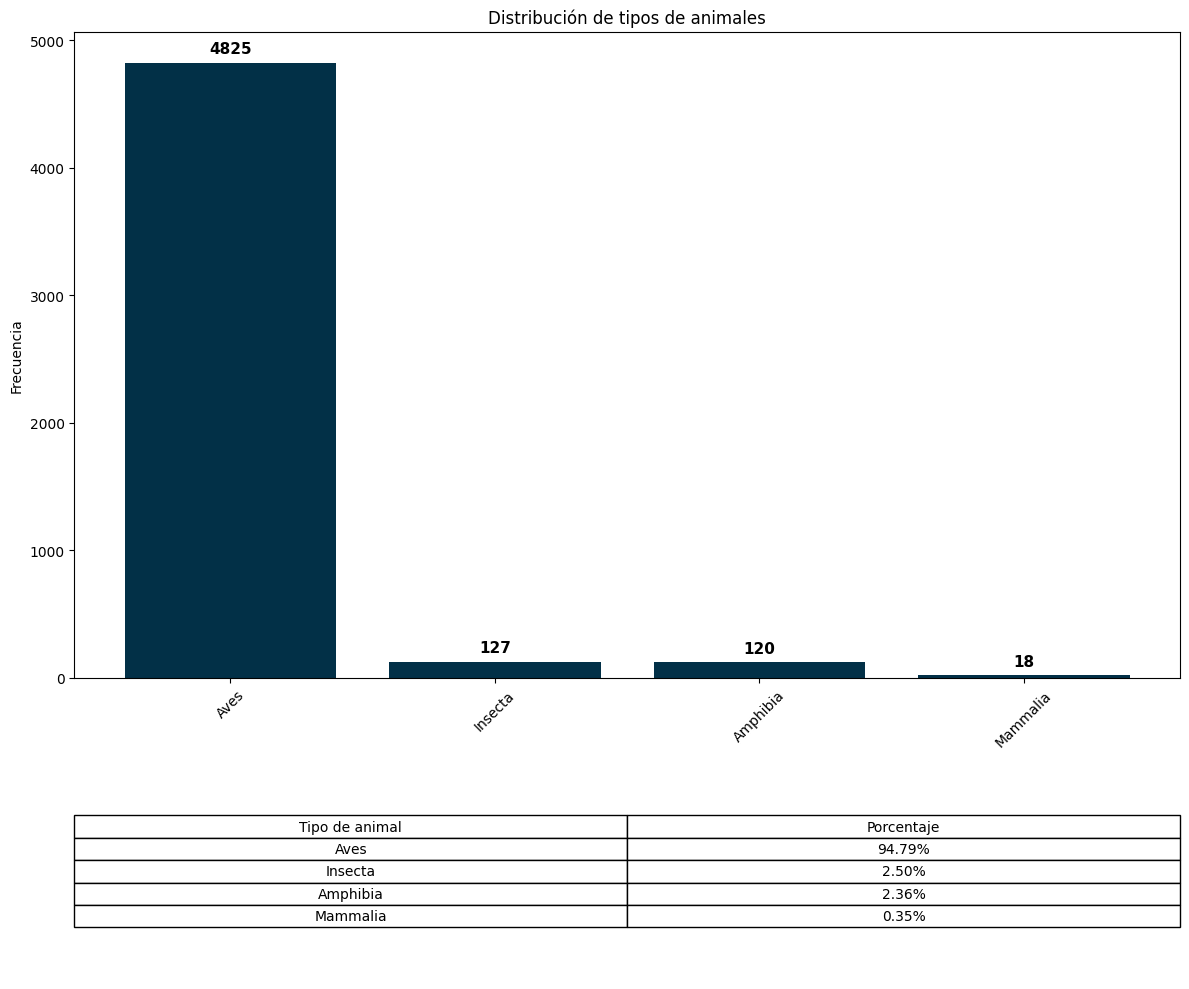

In [26]:
freqclase = datatraincolombia['class_name'].value_counts().reset_index()
freqclase.columns = ['class_name', 'count']
freqclase['percentage'] = (freqclase['count'] / len(datatraincolombia) * 100)

fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.4)

# Gráfico de barras
bars = axs[0].bar(freqclase['class_name'], freqclase['count'], color='#023047')
axs[0].set_title('Distribución de tipos de animales')
axs[0].set_ylabel('Frecuencia')
axs[0].tick_params(axis='x', rotation=45)

# Agregar frecuencias arriba de cada barra
for bar in bars:
    height = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, height + max(freqclase['count'])*0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tabla con porcentajes
cell_text = [[freqclase['class_name'].iloc[i], f"{freqclase['percentage'].iloc[i]:.2f}%"]
             for i in range(len(freqclase))]
axs[1].axis('tight')
axs[1].axis('off')
table = axs[1].table(cellText=cell_text,
                    colLabels=["Tipo de animal", "Porcentaje"],
                    loc='center',
                    cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.show()



El gráfico revela un marcado desbalance en la distribución de clases taxonómicas. De las 5090 observaciones, **4825 (94.79 %) corresponden a aves**, mientras que las demás clases están escasamente representadas: **127 registros de insectos, 120 de anfibios y apenas 18 de mamíferos**. Esto indica que la mayoría de los sonidos registrados proviene de aves.